# Exploratory Data Analysis

This notebook performs a minimal EDA of the two datasets:
- `subjects.csv`: participant metadata
- `timeseries.csv`: physiological time-series signals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

## 1. Load Data

In [2]:
subjects = pd.read_csv('data/subjects.csv')
ts = pd.read_csv('data/timeseries.csv')

print(f'subjects: {subjects.shape[0]} rows x {subjects.shape[1]} cols')
print(f'timeseries: {ts.shape[0]:,} rows x {ts.shape[1]} cols')

subjects: 500 rows x 8 cols
timeseries: 14,040,000 rows x 11 cols


## 2. Subjects Overview

In [3]:
subjects.head()

,SubjectID,STAI_T,STAI_S,Gender,Handedness,WearsGlasses,CalibrationError,BloodType
0,S001,37,36,F,R,0,0.396519,B
1,S002,45,38,F,L,0,0.937323,O
2,S003,40,39,M,R,1,0.270619,B
3,S004,34,30,M,L,1,0.387328,O
4,S005,25,40,M,R,0,0.263703,O


In [4]:
subjects.dtypes

SubjectID               str
STAI_T                int64
STAI_S                int64
Gender                  str
Handedness              str
WearsGlasses          int64
CalibrationError    float64
BloodType               str
dtype: object

In [5]:
subjects.isnull().sum()

SubjectID           0
STAI_T              0
STAI_S              0
Gender              0
Handedness          0
WearsGlasses        0
CalibrationError    0
BloodType           0
dtype: int64

In [6]:
subjects.describe()

,STAI_T,STAI_S,WearsGlasses,CalibrationError
count,500.000000,500.000000,500.000000,500.000000
mean,40.344000,39.026000,0.260000,0.323360
std,13.427817,10.982831,0.439074,0.240997
min,20.000000,20.000000,0.000000,0.050342
25%,30.000000,31.000000,0.000000,0.156750
50%,37.000000,37.000000,0.000000,0.262362
75%,50.000000,45.250000,1.000000,0.367792
max,80.000000,77.000000,1.000000,0.992948


### 2.1 STAI Score Distributions

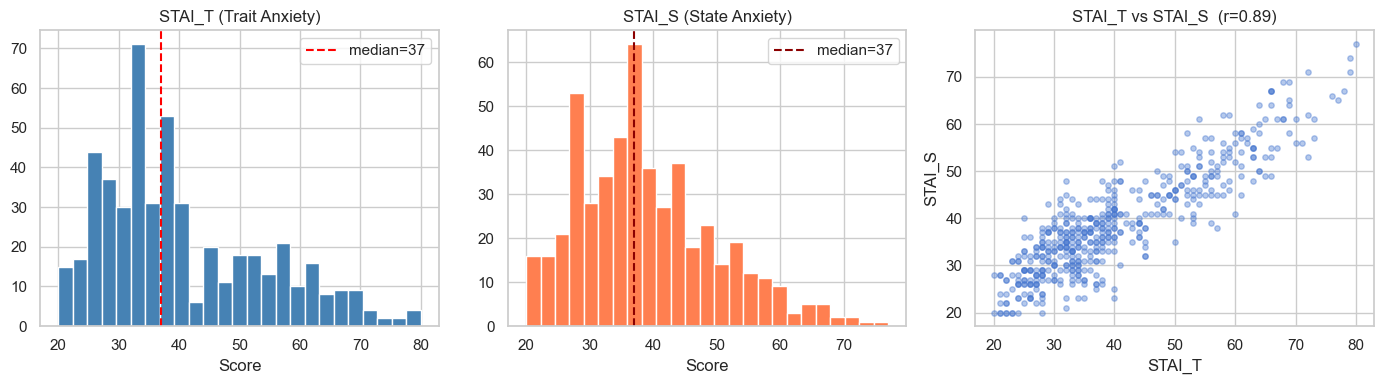

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# STAI_T
axes[0].hist(subjects['STAI_T'], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(subjects['STAI_T'].median(), color='red', linestyle='--', label=f'median={subjects["STAI_T"].median():.0f}')
axes[0].set_title('STAI_T (Trait Anxiety)')
axes[0].set_xlabel('Score')
axes[0].legend()

# STAI_S
axes[1].hist(subjects['STAI_S'], bins=25, color='coral', edgecolor='white')
axes[1].axvline(subjects['STAI_S'].median(), color='darkred', linestyle='--', label=f'median={subjects["STAI_S"].median():.0f}')
axes[1].set_title('STAI_S (State Anxiety)')
axes[1].set_xlabel('Score')
axes[1].legend()

# Scatter STAI_T vs STAI_S
axes[2].scatter(subjects['STAI_T'], subjects['STAI_S'], alpha=0.4, s=15)
corr = subjects[['STAI_T', 'STAI_S']].corr().iloc[0, 1]
axes[2].set_title(f'STAI_T vs STAI_S  (r={corr:.2f})')
axes[2].set_xlabel('STAI_T')
axes[2].set_ylabel('STAI_S')

plt.tight_layout()
plt.show()

### 2.2 Categorical Variables

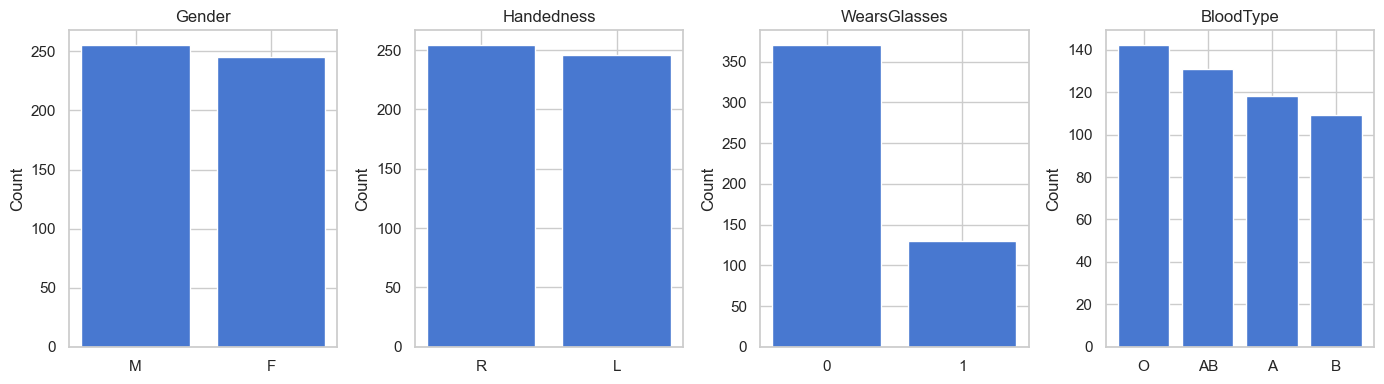

In [8]:
cat_cols = ['Gender', 'Handedness', 'WearsGlasses', 'BloodType']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    counts = subjects[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.3 CalibrationError Distribution

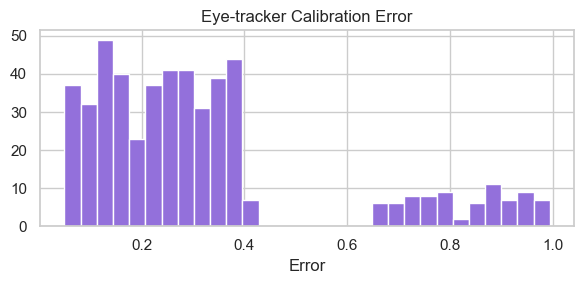

count    500.000000
mean       0.323360
std        0.240997
min        0.050342
25%        0.156750
50%        0.262362
75%        0.367792
max        0.992948
Name: CalibrationError, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(subjects['CalibrationError'], bins=30, color='mediumpurple', edgecolor='white')
ax.set_title('Eye-tracker Calibration Error')
ax.set_xlabel('Error')
plt.tight_layout()
plt.show()

print(subjects['CalibrationError'].describe())

## 3. Time-Series Overview

In [10]:
ts.head()

,SubjectID,DeviceTimestamp,CycleID,Phase,PupilDiameter,GazeX,GazeY,GazeZ,PulseBPM,PPG_SQI,MotionMag
0,S001,0,1,baseline,3.556082,-0.008417,0.010767,0.999907,65.901791,0.857084,0.083383
1,S001,16667,1,baseline,3.587611,-0.006079,0.009187,0.999939,65.901791,0.904661,0.060097
2,S001,33334,1,baseline,3.587292,-0.007796,0.008181,0.999936,65.901791,0.921183,0.073527
3,S001,50001,1,baseline,3.607923,-0.008068,0.009710,0.999920,65.901791,0.883678,0.063755
4,S001,66668,1,baseline,3.611525,-0.008401,0.008371,0.999930,65.901791,0.895014,0.064652


In [11]:
ts.dtypes

SubjectID              str
DeviceTimestamp      int64
CycleID              int64
Phase                  str
PupilDiameter      float64
GazeX              float64
GazeY              float64
GazeZ              float64
PulseBPM           float64
PPG_SQI            float64
MotionMag          float64
dtype: object

In [12]:
ts.isnull().sum()

SubjectID          0
DeviceTimestamp    0
CycleID            0
Phase              0
PupilDiameter      0
GazeX              0
GazeY              0
GazeZ              0
PulseBPM           0
PPG_SQI            0
MotionMag          0
dtype: int64

In [13]:
ts.describe()

,DeviceTimestamp,CycleID,PupilDiameter,GazeX,GazeY,GazeZ,PulseBPM,PPG_SQI,MotionMag
count,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07,1.404000e+07
mean,2.000112e+08,5.500406e+00,2.844748e+00,-1.450405e-01,-1.522549e-01,6.479631e-01,6.541615e+01,8.507411e-01,7.951728e-02
std,1.154829e+08,2.872513e+00,1.792470e+00,4.170652e-01,4.159952e-01,7.011442e-01,7.436218e+00,1.408912e-01,5.244148e-02
min,0.000000e+00,1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,3.500000e+01,0.000000e+00,5.000000e-02
25%,9.998533e+07,3.000000e+00,2.682745e+00,-2.440473e-01,-2.559473e-01,8.680830e-01,6.135669e+01,8.538054e-01,5.975445e-02
50%,2.000207e+08,6.000000e+00,3.354442e+00,-3.251767e-02,-3.698968e-02,9.622765e-01,6.526173e+01,8.772812e-01,7.069752e-02
75%,3.000393e+08,8.000000e+00,3.878072e+00,1.076385e-01,9.869292e-02,9.892313e-01,6.928826e+01,8.993544e-01,8.558918e-02
max,3.999913e+08,1.000000e+01,7.200000e+00,9.533955e-01,9.219631e-01,1.000000e+00,2.092987e+02,1.000000e+00,1.718127e+00


### 3.1 Phase and Cycle Distribution

In [14]:
print('Unique phases:', ts['Phase'].unique())
print('\nSamples per phase:')
print(ts['Phase'].value_counts())
print('\nCycles per subject (sample):')
print(ts.groupby('SubjectID')['CycleID'].nunique().value_counts())

Unique phases: <StringArray>
['baseline', 'relax', 'break']
Length: 3, dtype: str

Samples per phase:
Phase
relax       10529852
baseline     1755121
break        1755027
Name: count, dtype: int64

Cycles per subject (sample):
CycleID
10    500
Name: count, dtype: int64


In [15]:
# Samples per subject should be consistent
samples_per_subject = ts.groupby('SubjectID').size()
print('Samples per subject stats:')
print(samples_per_subject.describe())

Samples per subject stats:
count      500.000000
mean     28080.000000
std         57.024061
min      27914.000000
25%      28043.500000
50%      28082.000000
75%      28116.250000
max      28268.000000
dtype: float64


### 3.2 Timestamp Step Check (~60 Hz)

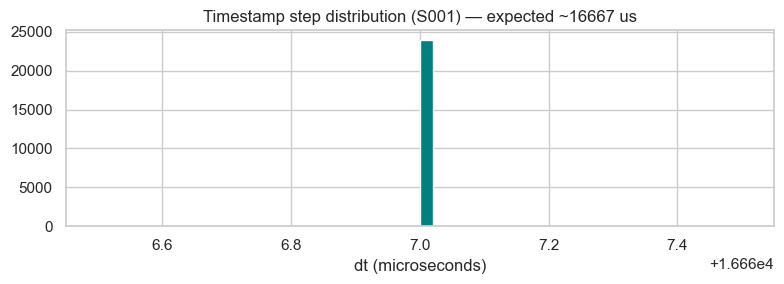

Median dt: 16667 us  ->  60.0 Hz


In [16]:
# Check timestamp increments for one subject to verify ~16667 us step
s001 = ts[ts['SubjectID'] == 'S001'].copy()
dt = s001['DeviceTimestamp'].diff().dropna()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(dt[dt > 0], bins=50, color='teal', edgecolor='white')
ax.set_title('Timestamp step distribution (S001) — expected ~16667 us')
ax.set_xlabel('dt (microseconds)')
plt.tight_layout()
plt.show()

print(f'Median dt: {dt[dt>0].median():.0f} us  ->  {1e6/dt[dt>0].median():.1f} Hz')

### 3.3 Duplicate Timestamps

In [17]:
dups = ts.duplicated(subset=['SubjectID', 'DeviceTimestamp'])
print(f'Duplicate (SubjectID, DeviceTimestamp) rows: {dups.sum()} ({100*dups.mean():.1f}%)')

Duplicate (SubjectID, DeviceTimestamp) rows: 2040000 (14.5%)


## 4. Signal Distributions by Phase

/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/2233135601.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True, notch=False)
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/2233135601.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True, notch=False)
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/2233135601.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True, notch=False)
/var/folders/lg/w8w

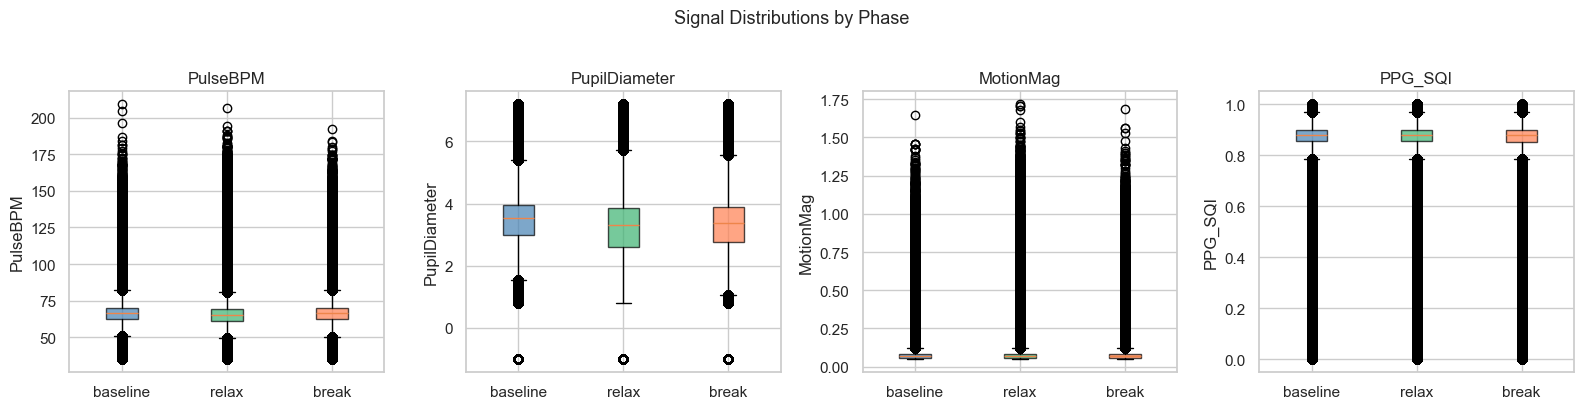

In [18]:
signal_cols = ['PulseBPM', 'PupilDiameter', 'MotionMag', 'PPG_SQI']
phase_order = ['baseline', 'relax', 'break']
palette = {'baseline': 'steelblue', 'relax': 'mediumseagreen', 'break': 'coral'}

fig, axes = plt.subplots(1, len(signal_cols), figsize=(16, 4))

for ax, col in zip(axes, signal_cols):
    data = [ts.loc[ts['Phase'] == p, col].dropna() for p in phase_order]
    bp = ax.boxplot(data, labels=phase_order, patch_artist=True, notch=False)
    for patch, phase in zip(bp['boxes'], phase_order):
        patch.set_facecolor(palette[phase])
        patch.set_alpha(0.7)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.suptitle('Signal Distributions by Phase', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4.1 Signal Stats per Phase

In [19]:
ts.groupby('Phase')[signal_cols].agg(['mean', 'median', 'std']).round(3)

PulseBPM                PupilDiameter               MotionMag         \
             mean  median    std          mean median    std      mean median   
Phase                                                                           
baseline   66.326  66.210  7.262         3.012  3.526  1.788     0.079  0.071   
break      66.324  66.174  7.624         2.894  3.370  1.762     0.080  0.071   
relax      65.113  64.949  7.408         2.809  3.316  1.796     0.080  0.071   

                PPG_SQI                
            std    mean median    std  
Phase                                  
baseline  0.052   0.854  0.878  0.134  
break     0.052   0.848  0.877  0.148  
relax     0.053   0.851  0.877  0.141

## 5. Example Single-Subject Time Series

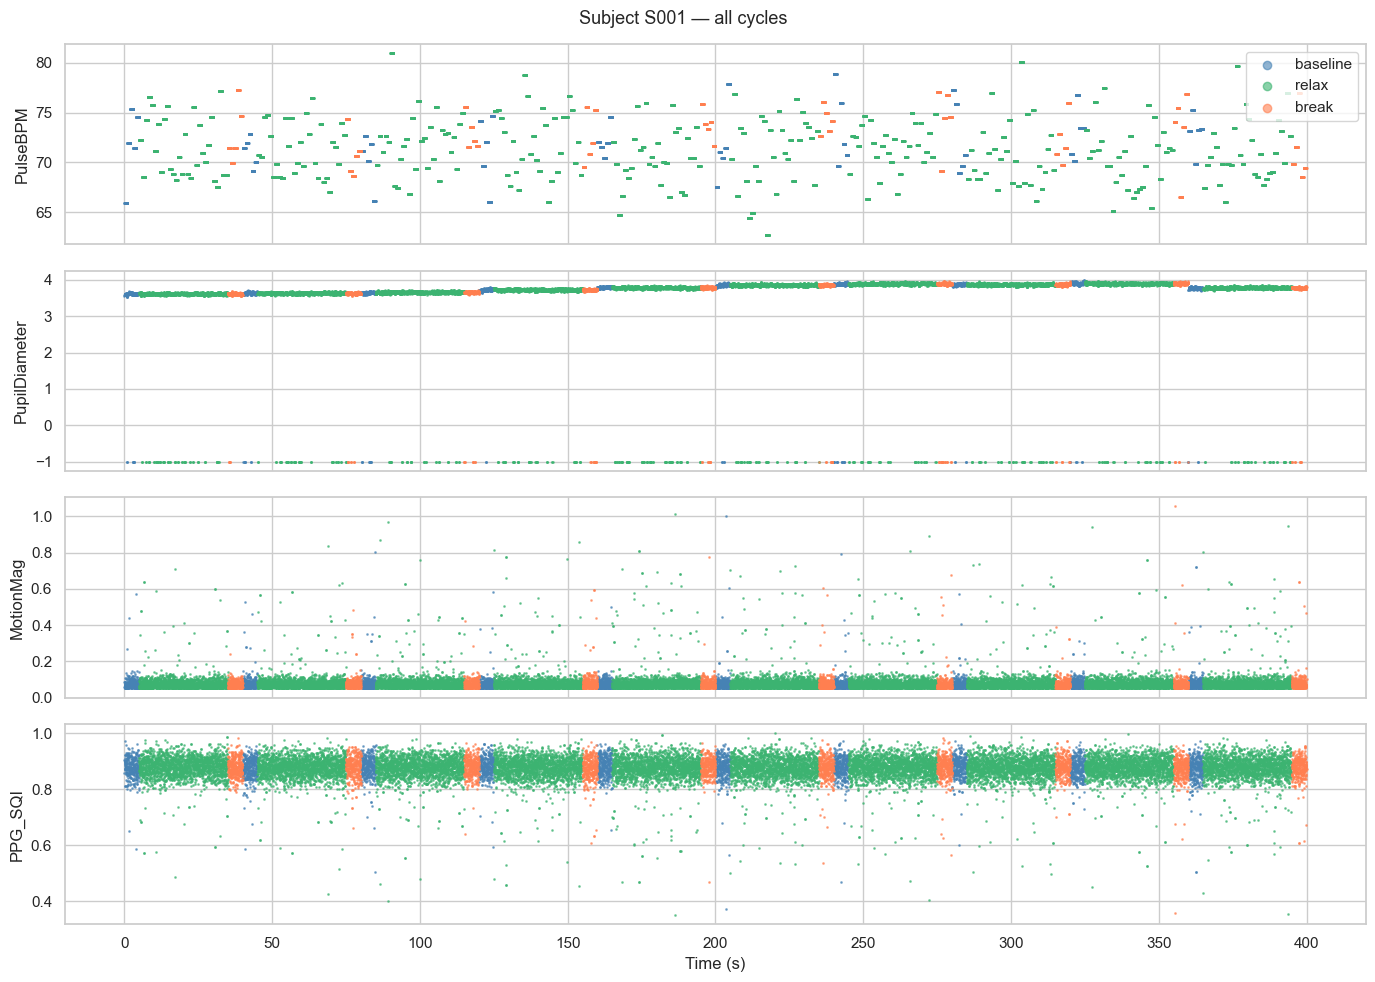

In [20]:
subj = 'S001'
df_subj = ts[ts['SubjectID'] == subj].sort_values('DeviceTimestamp').copy()
# Convert timestamp to seconds
df_subj['t_sec'] = df_subj['DeviceTimestamp'] / 1e6

phase_colors = {'baseline': 'steelblue', 'relax': 'mediumseagreen', 'break': 'coral'}

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
signals = ['PulseBPM', 'PupilDiameter', 'MotionMag', 'PPG_SQI']

for ax, sig in zip(axes, signals):
    for phase, color in phase_colors.items():
        mask = df_subj['Phase'] == phase
        ax.scatter(df_subj.loc[mask, 't_sec'], df_subj.loc[mask, sig],
                   s=1, c=color, label=phase, alpha=0.6)
    ax.set_ylabel(sig)

axes[-1].set_xlabel('Time (s)')
axes[0].legend(markerscale=6, loc='upper right')
fig.suptitle(f'Subject {subj} — all cycles', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Gaze Signal Overview

In [21]:
gaze_cols = ['GazeX', 'GazeY', 'GazeZ']
ts[gaze_cols].describe().round(4)

,GazeX,GazeY,GazeZ
count,1.404000e+07,1.404000e+07,1.404000e+07
mean,-1.450000e-01,-1.523000e-01,6.480000e-01
std,4.171000e-01,4.160000e-01,7.011000e-01
min,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,-2.440000e-01,-2.559000e-01,8.681000e-01
50%,-3.250000e-02,-3.700000e-02,9.623000e-01
75%,1.076000e-01,9.870000e-02,9.892000e-01
max,9.534000e-01,9.220000e-01,1.000000e+00


/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/3190842391.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True)
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/3190842391.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True)
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25971/3190842391.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=phase_order, patch_artist=True)


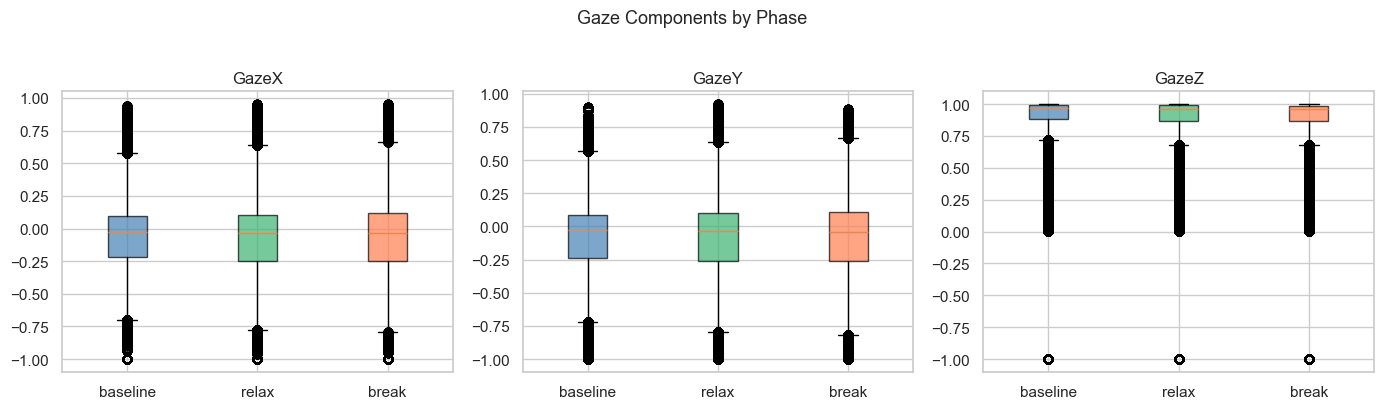

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, gaze_cols):
    data = [ts.loc[ts['Phase'] == p, col].dropna() for p in phase_order]
    bp = ax.boxplot(data, labels=phase_order, patch_artist=True)
    for patch, phase in zip(bp['boxes'], phase_order):
        patch.set_facecolor(palette[phase])
        patch.set_alpha(0.7)
    ax.set_title(col)

plt.suptitle('Gaze Components by Phase', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Preliminary Signal-Metadata Links

Quick check: does mean baseline heart rate correlate with STAI_T?

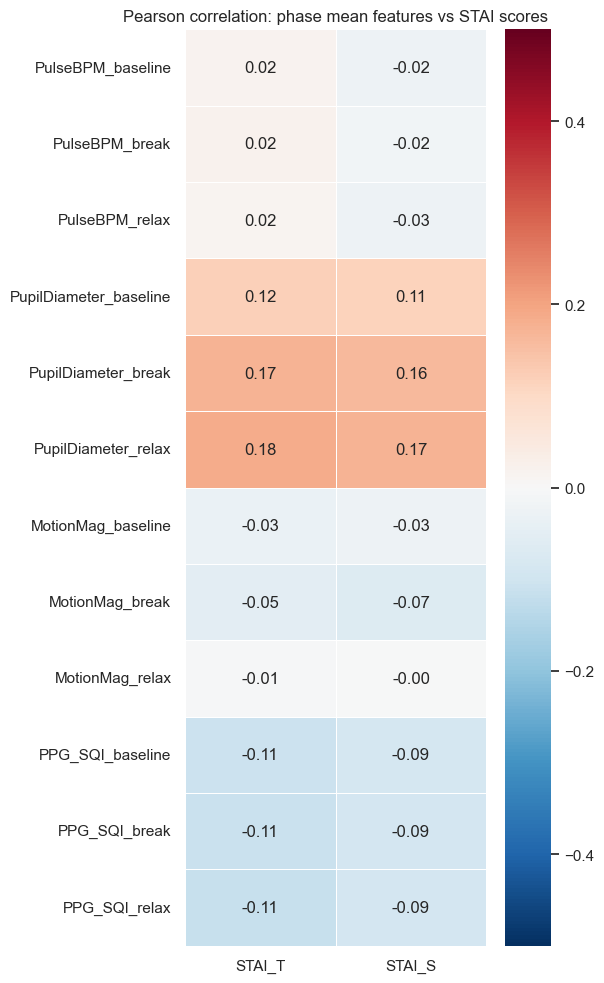

In [23]:
# Aggregate mean HR per subject per phase
phase_features = (
    ts.groupby(['SubjectID', 'Phase'])[signal_cols]
    .mean()
    .unstack('Phase')
)
phase_features.columns = ['_'.join(c) for c in phase_features.columns]
phase_features = phase_features.reset_index()

# Merge with subjects
merged = phase_features.merge(subjects, on='SubjectID')

# Quick correlations with STAI scores
stai_cols = ['STAI_T', 'STAI_S']
feature_cols = [c for c in phase_features.columns if c != 'SubjectID']
corr_matrix = merged[feature_cols + stai_cols].corr().loc[feature_cols, stai_cols]

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Pearson correlation: phase mean features vs STAI scores')
plt.tight_layout()
plt.show()

## 8. Summary

Key observations:

- **subjects.csv**: 500 participants, no missing values detected. STAI_T and STAI_S are correlated but distinct. The dataset includes subjects with a wide range of anxiety levels.
- **timeseries.csv**: ~60 Hz sampling confirmed. Some duplicate timestamps exist (to be dropped in preprocessing). Phase labels are `baseline`, `relax`, `break`; each subject has 10 cycles.
- **Signal quality (PPG_SQI)**: ranges 0–1; should be used to filter low-quality heart rate samples.
- **MotionMag**: right-skewed — most motion is small, with occasional spikes.
- **PupilDiameter**: visible variation across phases; preliminary inspection suggests values are physiologically plausible (2–7 mm range).
- **PulseBPM**: check whether it varies within a phase or is constant per trial (since HR from PPG may be updated at a lower rate than the eye-tracker).